In [16]:
from __future__ import annotations
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cross_decomposition import CCA
from scipy.stats import pearsonr 
from scipy import stats

###############################################################################
# Paths & constants
###############################################################################
PUPIL_ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\pupil_processed_clara")
EEG_ROOT   = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_theta_processed2")

FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']

OUT_TRIALS  = Path("trial_level_cca_fixedlag.csv")
OUT_SUBJECT = Path("subject_best_lag.csv")

SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
#SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
SHIFTS = np.arange(-100, 101)      # ±1 s at 100 Hz → samples
WIN_OFFSET1 = 200                  # discard first 200 ms
WIN_OFFSET2 = 110                  # discard last 110 ms

###############################################################################
# Helper functions
###############################################################################

def normalise_eeg(x: np.ndarray) -> np.ndarray:
    """Centre each channel and scale so Σ x² = 1 over time×channels."""
    x = x - x.mean(axis=0, keepdims=True)
    scale = np.sqrt(np.mean(x**2))
    return x / scale


def cca_corr(eeg: np.ndarray, pupil: np.ndarray) -> float:
    """Canonical correlation (single component)."""
    cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
    cca.fit(eeg, pupil)
    u, v = cca.transform(eeg, pupil)
    return float(np.corrcoef(u[:, 0], v[:, 0])[0, 1])


In [17]:
def load_all_trials(
        sub: int,
        eeg_root: Path = EEG_ROOT,
        pupil_root: Path = PUPIL_ROOT,
        min_len: int = 40,
        max_len_diff: int = 30,
) -> list[tuple[np.ndarray, np.ndarray, dict]]:
    """
    Load *all* valid EEG-pupil trial pairs for one subject.

    Parameters
    ----------
    sub : int
        Numeric subject ID (e.g. 42).
    eeg_root, pupil_root : Path
        Roots of the pre-processed EEG and pupil folders.
    min_len : int
        Minimum number of samples a pupil trace must have to be accepted.
    max_len_diff : int
        Reject trial if |len(pupil)-len(eeg)| exceeds this.
    Returns
    -------
    trials : list of (eeg, pupil_z, meta)
        * eeg        - (T × n_channels) float64, already centred/scaled
        * pupil_z    - (T × 1) float64, per-trial z-scored
        * meta       - dict with subject/condition/load/epoch
    """
    trials = []
    sub_tag = f"sub-{sub:03d}"
    eeg_sub  = eeg_root   / sub_tag
    pupil_sub = pupil_root / sub_tag

    if not eeg_sub.exists():
        print(f"{sub_tag}: EEG folder missing - skipped")
        return trials

    # iterate condition (“control” / “memory”) and load (“05” / “09” / “13”)
    for cond_path in sorted(eeg_sub.iterdir()):
        if not cond_path.is_dir():
            continue
        for load_path in sorted(cond_path.iterdir()):
            if not load_path.is_dir():
                continue

            # matching pupil directory
            pupil_path = pupil_sub / cond_path.name / load_path.name
            if not pupil_path.exists():
                continue

            eeg_epochs   = sorted(load_path.glob("trial_*.csv"))
            pupil_epochs = sorted(pupil_path.glob("trial_*.csv"))
            common = {f.name for f in eeg_epochs} & {f.name for f in pupil_epochs}
            if not common:
                continue

            for fname in sorted(common):
                eeg_df = pd.read_csv(load_path / fname, comment="#", index_col=0)
                pupil_df = pd.read_csv(pupil_path / fname, comment="#",
                                       names=["time", "diameter_z"], index_col=0)

                eeg   = eeg_df.values.astype(float)
                pupil = pupil_df["diameter_z"].values.astype(float)

                # basic validity checks
                if len(pupil) < min_len or abs(len(pupil) - len(eeg)) > max_len_diff:
                    continue

                # normalise signals ----------------------------------------
                eeg_norm = normalise_eeg(eeg)           # your helper from before
                pupil_z  = ((pupil - pupil.mean()) / pupil.std(ddof=0))

                # same number of samples
                T = min(len(eeg_norm), len(pupil_z))
                eeg_norm = eeg_norm[0:T, :]  # (T × n_channels)
                pupil_z  = pupil_z[0:T].reshape(-1, 1)

                meta = {
                    "subject":   sub_tag,
                    "condition": cond_path.name,
                    "load":      int(load_path.name),
                    "epoch":     fname
                }
                trials.append((eeg_norm, pupil_z, meta))

    return trials

from typing import List, Tuple
import numpy as np

def split_trials_by_condition(
        trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        memory_label: str = "memory",
        control_label: str = "control"
) -> Tuple[List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]]]:
    """
    Separate a mixed list of (eeg, pupil, meta) trial tuples into memory-condition and control-condition sub-lists.

    Parameters
    ----------
    trials : list of tuples
        Each tuple = (eeg_array, pupil_array, meta_dict).
        meta_dict must contain a key 'condition'.
    memory_label : str
        The value of meta['condition'] that marks a memory trial.
    control_label : str
        The value of meta['condition'] that marks a control trial.

    Returns
    -------
    memory_trials  : list[tuple]
    control_trials : list[tuple]
    """
    memory_trials  = []
    control_trials = []

    for eeg, pupil, meta in trials:
        cond = meta.get("condition", "").lower()
        if cond == memory_label:
            memory_trials.append((eeg, pupil, meta))
        elif cond == control_label:
            control_trials.append((eeg, pupil, meta))
        else: raise ValueError(f"Unknown condition label: {cond}")

    return memory_trials, control_trials


In [18]:
import numpy as np
from typing import List, Tuple, Dict

def search_best_lag(
        train_trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        shifts: np.ndarray = SHIFTS,
        return_curve: bool = False
) -> Tuple[float, int, Dict[int, float] | None]:
    """
    Search for the lag (sample shift) that maximises the mean canonical
    correlation between EEG and pupil traces in a training set.

    Parameters
    ----------
    train_trials : list of (eeg, pupil_z, meta)
        Each eeg  : 2-D array [time × channels or CCA-components]
        Each pupil: 1-D array [time]
    shifts : np.ndarray
        Array of integer lag shifts (positive = EEG is moved forward).
    return_curve : bool, default False
        If True, also return the full {shift: mean_r} dictionary.

    Returns
    -------
    best_corr : float
        Highest mean canonical correlation found.
    best_shift : int
        Shift (samples) that maximised the correlation.
    mean_r_per_shift : dict | None
        Only when `return_curve` is True.
    """
    win = slice(WIN_OFFSET1, -WIN_OFFSET2)         # common window
    mean_r_per_shift: Dict[int, float] = {}

    for s in shifts:                               # <-- loop over *shifts*, not SHIFTS
        rs = []
        for eeg, pupil_z, _ in train_trials:
            eeg_shifted = np.roll(eeg, s, axis=0)[win]
            r = cca_corr(eeg_shifted, pupil_z[win])
            rs.append(r)
        mean_r_per_shift[s] = float(np.mean(rs))   # cast to plain float for JSON-ability

    best_shift = max(mean_r_per_shift, key=mean_r_per_shift.get)
    best_corr  = mean_r_per_shift[best_shift]

    if return_curve:
        return best_corr, best_shift, mean_r_per_shift
    else:
        return best_corr, best_shift, None


In [ ]:
from typing import List, Tuple, Optional

# trials  : list of (eeg, pupil_z, meta)   -- the tuples returned by load_all_trials
# shift   : integer sample shift (best_shift)
# win     : slice or None                  -- cropping window (set to None if the
#                                            trials are already pre-trimmed)
def concat_trials(
        trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        shift: int = 0,
        win: Optional[slice] = None
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Concatenate a list of trials into one long matrix pair ready for CCA.

    Returns
    -------
    X  : ndarray, shape (Σ Tᵢ, n_channels)
    Y  : ndarray, shape (Σ Tᵢ, 1)
    """
    X_blocks, Y_blocks = [], []

    for eeg, pupil_z, _ in trials:
        # 1. roll *inside* the trial so samples never cross trial boundaries
        eeg_shift = np.roll(eeg, shift, axis=0)

        # 2. optional windowing (do it once here if you did **not** crop in loader)
        if win is not None:
            eeg_shift = eeg_shift[win]
            pupil_seg = pupil_z[win]
        else:
            pupil_seg = pupil_z          # already trimmed earlier

        # 3. stack
        X_blocks.append(eeg_shift)
        Y_blocks.append(pupil_seg)

    X = np.vstack(X_blocks)
    Y = np.vstack(Y_blocks)
    return X, Y

def iterate_trials(trials, shift, win):
    """Yield (eeg_shifted, pupil_z_windowed, meta) one by one."""
    for eeg, pupil_z, meta in trials:
        eeg_s = np.roll(eeg, shift, axis=0)[win]
        yield eeg_s, pupil_z[win], meta.copy()

import pandas as pd
import json
from pathlib import Path

def save_cca_weights(cca, subject_tag, lag_ms, eeg_ch_names, condition, out_dir=Path("weights")):
    """
    Dump EEG & pupil canonical weights to CSV/JSON for one subject.

    Parameters
    ----------
    cca            : fitted sklearn.cross_decomposition.CCA
    subject_tag    : "sub-042"
    lag_ms         : e.g. -90
    eeg_ch_names   : list[str] same order as columns in your trial matrices
    out_dir        : destination folder (created if missing)
    """
    out_dir.mkdir(parents=True, exist_ok=True)

    # ------- Pupil weight -> JSON ---------------------------------------
    w_pupil_og = float(cca.y_weights_[0, 0])   # scalar in 1-dim pupil case
    w_pupil = 1.0
    with open(out_dir / f"{subject_tag}_pupil_weight_{condition}_{lag_ms:+d}ms.json", "w") as fh:
        json.dump({"weight": w_pupil}, fh, indent=2)
    
    # ------- EEG weights -> tidy CSV ------------------------------------
    w_eeg = cca.x_weights_[:, 0] / w_pupil_og
    w_eeg = pd.Series(w_eeg, index=eeg_ch_names, name="weight")
    w_eeg.index.name = "channel"
    w_eeg.to_csv(out_dir / f"{subject_tag}_eeg_weights_{condition}_{lag_ms:+d}ms.csv")

    print(f"saved weights for {subject_tag} (lag {lag_ms:+d} ms)")



In [20]:
best_shift_by_sub = {33: -5, 34: 32, 35: -8, 36: -59, 38: -1, 39: 2, 40: 100, 41: -10, 42: -80, 43: 70, 44: -10, 45: 42, 46: -68, 47: 100, 48: -63, 49: 46, 50: 91, 51: 100, 52: 81, 54: 63, 55: -38, 56: 23, 57: 36, 58: 46, 59: -7, 60: 100, 62: -9, 63: 0, 64: 53, 65: -6, 67: 2, 68: 96, 69: 28, 70: 16, 71: 74, 72: 0, 73: 38, 74: -100, 75: 32, 76: 100, 77: 76, 79: 80, 80: -1, 81: 64, 82: -44, 83: -52, 85: 37, 86: 100, 87: 24, 88: 100, 89: -100, 91: -5, 92: 41, 93: 100, 95: -7, 97: -56, 98: 69}
print(best_shift_by_sub)

{33: -5, 34: 32, 35: -8, 36: -59, 38: -1, 39: 2, 40: 100, 41: -10, 42: -80, 43: 70, 44: -10, 45: 42, 46: -68, 47: 100, 48: -63, 49: 46, 50: 91, 51: 100, 52: 81, 54: 63, 55: -38, 56: 23, 57: 36, 58: 46, 59: -7, 60: 100, 62: -9, 63: 0, 64: 53, 65: -6, 67: 2, 68: 96, 69: 28, 70: 16, 71: 74, 72: 0, 73: 38, 74: -100, 75: 32, 76: 100, 77: 76, 79: 80, 80: -1, 81: 64, 82: -44, 83: -52, 85: 37, 86: 100, 87: 24, 88: 100, 89: -100, 91: -5, 92: 41, 93: 100, 95: -7, 97: -56, 98: 69}


**K FOLDS**

### Trainin on stratified mem and ctrl trials, K = 5, USE_PER_FOLD_LAF = T, SHIFT = (-100, 101)

In [6]:
from sklearn.model_selection import StratifiedKFold
from sklearn.cross_decomposition import CCA
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
from scipy import stats

K = 5                              # choose your K
SHIFT_GRID = np.arange(-100, 101)    # e.g. ±200 ms at 10 ms steps → adjust to your data rate (×10 ms later)
USE_PER_FOLD_LAG = True            # set False to keep best_shift_by_sub[subj]

rows_subject = []   # final per-subject (averaged across folds)
rows_folds   = []   # optional per-fold diagnostics

def pick_best_shift_cv(train_trials, train_labels, win, n_splits=3):
    """Inner CV to choose lag only from training data."""
    n_pos = (np.array(train_labels) == "memory").sum()
    n_neg = len(train_labels) - n_pos
    n_splits = max(2, min(n_splits, n_pos, n_neg))  # guard

    skf_inner = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    y_inner = np.array(train_labels)

    best_shift, best_score = 0, -np.inf
    for s in SHIFT_GRID:
        fold_scores = []
        for tr_idx, va_idx in skf_inner.split(np.zeros(len(y_inner)), y_inner):
            tr_trials = [train_trials[i] for i in tr_idx]
            va_trials = [train_trials[i] for i in va_idx]

            X_tr, Y_tr = concat_trials(tr_trials, shift=int(s), win=win)
            X_va, Y_va = concat_trials(va_trials, shift=int(s), win=win)

            cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
            cca.fit(X_tr, Y_tr)

            u, v = cca.transform(X_va, Y_va)
            r, _ = pearsonr(u[:, 0], v[:, 0])
            fold_scores.append(r)

        mean_score = np.nanmean(fold_scores)  # average val r across inner folds
        if mean_score > best_score:
            best_score, best_shift = mean_score, int(s)
    return best_shift

# --------------------------------------------------------------
# main per-subject loop with K-fold CV
# --------------------------------------------------------------
all_subject_rows = []  # collect for group stats if you want per-fold rows too

for subj in SUBJECTS:
    print(f"Processing subject {subj:02d}...")

    trials = load_all_trials(subj)                      # list of (eeg, pupil)
    trials_memory, trials_control = split_trials_by_condition(trials)

    n_mem, n_ctl = len(trials_memory), len(trials_control)
    if n_mem < 2 or n_ctl < 2:
        print(f"Subject {subj:02d} skipped - not enough trials per condition.")
        continue

    # Build a single list + labels so we can stratify
    all_trials = [(t, "memory") for t in trials_memory] + [(t, "control") for t in trials_control]
    labels     = np.array([lab for _, lab in all_trials])

    # Choose an effective K per subject so each fold has both conditions
    k_eff = max(2, min(K, n_mem, n_ctl))
    skf = StratifiedKFold(n_splits=k_eff, shuffle=True, random_state=42)

    win = slice(WIN_OFFSET1, -WIN_OFFSET2)

    fold_rs_mem  = []
    fold_rs_ctrl = []

    for fold, (tr_idx, te_idx) in enumerate(skf.split(np.zeros(len(labels)), labels), start=1):
        train_trials = [all_trials[i][0] for i in tr_idx]
        test_pairs   = [all_trials[i]       for i in te_idx]

        test_mem  = [t for (t, lab) in test_pairs if lab == "memory"]
        test_ctrl = [t for (t, lab) in test_pairs if lab == "control"]
        if len(test_mem) == 0 or len(test_ctrl) == 0:
            # extremely rare with stratification, but guard anyway
            continue

        # pick lag
        if USE_PER_FOLD_LAG:
            train_labs = [labels[i] for i in tr_idx]
            best_shift = pick_best_shift_cv(train_trials, train_labs, win)
        else:
            best_shift = int(best_shift_by_sub.get(subj, 0))  # assumes it's from independent data

        # Fit on training (both conditions)
        X_tr, Y_tr = concat_trials(train_trials, shift=best_shift, win=win)
        cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
        cca.fit(X_tr, Y_tr)

        # Evaluate MEMORY
        X_mem_te, Y_mem_te = concat_trials(test_mem,  shift=best_shift, win=win)
        u, v = cca.transform(X_mem_te, Y_mem_te)
        r_mem, p_mem = pearsonr(u[:, 0], v[:, 0])

        # Evaluate CONTROL
        X_ctl_te, Y_ctl_te = concat_trials(test_ctrl, shift=best_shift, win=win)
        u, v = cca.transform(X_ctl_te, Y_ctl_te)
        r_ctl, p_ctl = pearsonr(u[:, 0], v[:, 0])

        fold_rs_mem.append(r_mem)
        fold_rs_ctrl.append(r_ctl)

        rows_folds.append({
            "subject": subj, "fold": fold,
            "lag_ms": best_shift * 10,
            "r_memory": float(r_mem), "r_control": float(r_ctl)
        })

    # Aggregate across folds → one number per condition per subject
    if len(fold_rs_mem) == 0 or len(fold_rs_ctrl) == 0:
        print(f"Subject {subj:02d} had empty folds, skipped.")
        continue

    # (Optional) Fisher-z before averaging if your r's get large
    # mem_mean = np.tanh(np.mean(np.arctanh(np.clip(fold_rs_mem, -0.999999, 0.999999))))
    # ctl_mean = np.tanh(np.mean(np.arctanh(np.clip(fold_rs_ctrl, -0.999999, 0.999999))))
    mem_mean = float(np.mean(fold_rs_mem))
    ctl_mean = float(np.mean(fold_rs_ctrl))

    rows_subject.append({"subject": subj, "condition": "memory",  "r": mem_mean})
    rows_subject.append({"subject": subj, "condition": "control", "r": ctl_mean})

# -----------------------------
# Save + group-level statistics
# -----------------------------
pd.DataFrame(rows_folds).to_csv("subject_fold_cca_kfold_details.csv", index=False)
pd.DataFrame(rows_subject).to_csv("subject_level_cca_kfold.csv", index=False)
print("Saved subject_fold_cca_kfold_details.csv and subject_level_cca_kfold.csv")

df_subj = pd.read_csv("subject_level_cca_kfold.csv")
df_wide = df_subj.pivot(index="subject", columns="condition", values="r")

# Paired t-test (memory > control), averaged across folds per subject
dfree = len(df_wide) - 1
t2, p2 = stats.ttest_rel(df_wide["memory"], df_wide["control"])
p_one = p2/2 if t2 > 0 else 1 - p2/2
print(f"Paired t-test (K-fold, per-subject means): t={t2:.3f}, p_two={p2:.4f}, p_one(mem>ctl)={p_one:.4f}, df={dfree}")


Processing subject 33...
Processing subject 34...
Processing subject 35...
Processing subject 36...
Processing subject 38...
Processing subject 39...
Processing subject 40...
Processing subject 41...
Processing subject 42...
Processing subject 43...
Processing subject 44...
Processing subject 45...
Processing subject 46...
Processing subject 47...
Processing subject 48...
Processing subject 49...
Processing subject 50...
Processing subject 51...
Processing subject 52...
Processing subject 54...
Processing subject 55...
Processing subject 56...
Processing subject 57...
Processing subject 58...
Processing subject 59...
Processing subject 60...
Processing subject 62...
Processing subject 63...
Processing subject 64...
Processing subject 65...
Processing subject 67...
Processing subject 68...
Subject 68 skipped - not enough trials per condition.
Processing subject 69...
Processing subject 70...
Processing subject 71...
Processing subject 72...
Processing subject 73...
Processing subject 74

### Trainin on stratified mem and ctrl trials, K = 3, USE_PER_FOLD_LAF = F

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.cross_decomposition import CCA
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
from scipy import stats

K = 3                              # choose your K
SHIFT_GRID = np.arange(-20, 21)    # e.g. ±200 ms at 10 ms steps → adjust to your data rate (×10 ms later)
USE_PER_FOLD_LAG = False            # set False to keep best_shift_by_sub[subj]

rows_subject = []   # final per-subject (averaged across folds)
rows_folds   = []   # optional per-fold diagnostics

def pick_best_shift_cv(train_trials, train_labels, win, n_splits=3):
    """Inner CV to choose lag only from training data."""
    n_pos = (np.array(train_labels) == "memory").sum()
    n_neg = len(train_labels) - n_pos
    n_splits = max(2, min(n_splits, n_pos, n_neg))  # guard

    skf_inner = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    y_inner = np.array(train_labels)

    best_shift, best_score = 0, -np.inf
    for s in SHIFT_GRID:
        fold_scores = []
        for tr_idx, va_idx in skf_inner.split(np.zeros(len(y_inner)), y_inner):
            tr_trials = [train_trials[i] for i in tr_idx]
            va_trials = [train_trials[i] for i in va_idx]

            X_tr, Y_tr = concat_trials(tr_trials, shift=int(s), win=win)
            X_va, Y_va = concat_trials(va_trials, shift=int(s), win=win)

            cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
            cca.fit(X_tr, Y_tr)

            u, v = cca.transform(X_va, Y_va)
            r, _ = pearsonr(u[:, 0], v[:, 0])
            fold_scores.append(r)

        mean_score = np.nanmean(fold_scores)  # average val r across inner folds
        if mean_score > best_score:
            best_score, best_shift = mean_score, int(s)
    return best_shift

def fisher_z(r):
    r = np.clip(r, -0.999999, 0.999999)
    return np.arctanh(r)

def z_to_r(z):
    return np.tanh(z)

# --------------------------------------------------------------
# main per-subject loop with K-fold CV
# --------------------------------------------------------------
all_subject_rows = []  # collect for group stats if you want per-fold rows too

for subj in SUBJECTS:
    print(f"Processing subject {subj:02d}...")

    trials = load_all_trials(subj)                      # list of (eeg, pupil)
    trials_memory, trials_control = split_trials_by_condition(trials)

    n_mem, n_ctl = len(trials_memory), len(trials_control)
    if n_mem < 2 or n_ctl < 2:
        print(f"Subject {subj:02d} skipped - not enough trials per condition.")
        continue

    # Build a single list + labels so we can stratify
    all_trials = [(t, "memory") for t in trials_memory] + [(t, "control") for t in trials_control]
    labels     = np.array([lab for _, lab in all_trials])

    # Choose an effective K per subject so each fold has both conditions
    k_eff = max(2, min(K, n_mem, n_ctl))
    skf = StratifiedKFold(n_splits=k_eff, shuffle=True, random_state=42)

    win = slice(WIN_OFFSET1, -WIN_OFFSET2)

    fold_rs_mem  = []
    fold_rs_ctrl = []

    for fold, (tr_idx, te_idx) in enumerate(skf.split(np.zeros(len(labels)), labels), start=1):
        train_trials = [all_trials[i][0] for i in tr_idx]
        test_pairs   = [all_trials[i]       for i in te_idx]

        test_mem  = [t for (t, lab) in test_pairs if lab == "memory"]
        test_ctrl = [t for (t, lab) in test_pairs if lab == "control"]
        if len(test_mem) == 0 or len(test_ctrl) == 0:
            # extremely rare with stratification, but guard anyway
            continue

        # pick lag
        if USE_PER_FOLD_LAG:
            train_labs = [labels[i] for i in tr_idx]
            best_shift = pick_best_shift_cv(train_trials, train_labs, win)
        else:
            best_shift = int(best_shift_by_sub.get(subj, 0))  # assumes it's from independent data

        # Fit on training (both conditions)
        X_tr, Y_tr = concat_trials(train_trials, shift=best_shift, win=win)
        cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
        cca.fit(X_tr, Y_tr)

        # Evaluate MEMORY
        X_mem_te, Y_mem_te = concat_trials(test_mem,  shift=best_shift, win=win)
        u, v = cca.transform(X_mem_te, Y_mem_te)
        r_mem, p_mem = pearsonr(u[:, 0], v[:, 0])

        # Evaluate CONTROL
        X_ctl_te, Y_ctl_te = concat_trials(test_ctrl, shift=best_shift, win=win)
        u, v = cca.transform(X_ctl_te, Y_ctl_te)
        r_ctl, p_ctl = pearsonr(u[:, 0], v[:, 0])

        if p_mem > 0.05 or p_ctl > 0.05:
            print(f"Subject {subj:02d} fold {fold} skipped - non-significant correlations (p_mem={p_mem:.3f}, p_ctl={p_ctl:.3f}).")

        fold_rs_mem.append(r_mem)
        fold_rs_ctrl.append(r_ctl)

        rows_folds.append({
            "subject": subj, "fold": fold,
            "lag_ms": best_shift * 10,
            "r_memory": float(r_mem), "r_control": float(r_ctl)
        })

    # Aggregate across folds → one number per condition per subject
    if len(fold_rs_mem) == 0 or len(fold_rs_ctrl) == 0:
        print(f"Subject {subj:02d} had empty folds, skipped.")
        continue

    # (Optional) Fisher-z before averaging if your r's get large
    # mem_mean = np.tanh(np.mean(np.arctanh(np.clip(fold_rs_mem, -0.999999, 0.999999))))
    # ctl_mean = np.tanh(np.mean(np.arctanh(np.clip(fold_rs_ctrl, -0.999999, 0.999999))))
    mem_mean = float(np.mean(fold_rs_mem))
    ctl_mean = float(np.mean(fold_rs_ctrl))

    rows_subject.append({"subject": subj, "condition": "memory",  "r": mem_mean})
    rows_subject.append({"subject": subj, "condition": "control", "r": ctl_mean})

# -----------------------------
# Save + group-level statistics
# -----------------------------
pd.DataFrame(rows_folds).to_csv("subject_fold_cca_kfold_detailsFalse.csv", index=False)
pd.DataFrame(rows_subject).to_csv("subject_level_cca_kfoldFalse.csv", index=False)
print("Saved subject_fold_cca_kfold_detailsFalse.csv and subject_level_cca_kfoldFalse.csv")

df_subj = pd.read_csv("subject_level_cca_kfoldFalse.csv")
df_wide = df_subj.pivot(index="subject", columns="condition", values="r")

# Paired t-test (memory > control), averaged across folds per subject
dfree = len(df_wide) - 1
t2, p2 = stats.ttest_rel(df_wide["memory"], df_wide["control"])
p_one = p2/2 if t2 > 0 else 1 - p2/2
print(f"Paired t-test (K-fold, per-subject means): t={t2:.3f}, p_two={p2:.4f}, p_one(mem>ctl)={p_one:.4f}, df={dfree}")


Processing subject 33...
Subject 33 fold 1 skipped - non-significant correlations (p_mem=0.000, p_ctl=0.098).
Subject 33 fold 2 skipped - non-significant correlations (p_mem=0.062, p_ctl=0.000).
Subject 33 fold 3 skipped - non-significant correlations (p_mem=0.000, p_ctl=0.873).
Processing subject 34...
Subject 34 fold 1 skipped - non-significant correlations (p_mem=0.006, p_ctl=0.448).
Subject 34 fold 2 skipped - non-significant correlations (p_mem=0.000, p_ctl=0.199).
Processing subject 35...
Subject 35 fold 2 skipped - non-significant correlations (p_mem=0.104, p_ctl=0.000).
Processing subject 36...
Subject 36 fold 1 skipped - non-significant correlations (p_mem=0.000, p_ctl=0.110).
Subject 36 fold 3 skipped - non-significant correlations (p_mem=0.000, p_ctl=0.987).
Processing subject 38...
Processing subject 39...
Processing subject 40...
Processing subject 41...
Subject 41 fold 1 skipped - non-significant correlations (p_mem=0.699, p_ctl=0.000).
Processing subject 42...
Processing

In [56]:
for subj in SUBJECTS:

    trials = load_all_trials(subj)                      # list of (eeg, pupil)
    trials_memory, trials_control = split_trials_by_condition(trials)

    n_mem, n_ctl = len(trials_memory), len(trials_control)
    if n_mem < 2 or n_ctl < 2:
        print(f"Subject {subj:02d} skipped - not enough trials per condition.")
        continue
    else:
        print(f"Subject {subj:02d} has {n_mem} memory and {n_ctl} control trials.")

Subject 33 has 106 memory and 54 control trials.
Subject 34 has 97 memory and 45 control trials.
Subject 35 has 16 memory and 15 control trials.
Subject 36 has 43 memory and 26 control trials.
Subject 38 has 59 memory and 32 control trials.
Subject 39 has 75 memory and 50 control trials.
Subject 40 has 74 memory and 52 control trials.
Subject 41 has 108 memory and 53 control trials.
Subject 42 has 102 memory and 47 control trials.
Subject 43 has 93 memory and 49 control trials.
Subject 44 has 98 memory and 52 control trials.
Subject 45 has 64 memory and 42 control trials.
Subject 46 has 8 memory and 6 control trials.
Subject 47 has 41 memory and 33 control trials.
Subject 48 has 50 memory and 43 control trials.
Subject 49 has 66 memory and 40 control trials.
Subject 50 has 108 memory and 53 control trials.
Subject 51 has 44 memory and 22 control trials.
Subject 52 has 40 memory and 28 control trials.
Subject 54 has 91 memory and 50 control trials.
Subject 55 has 90 memory and 46 contro

### Trainin on only MEM trials, K = 3, USE_PER_FOLD_LAG = F

In [ ]:
from sklearn.model_selection import KFold
from sklearn.cross_decomposition import CCA
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
from scipy import stats

K = 5                               # folds over MEMORY trials only
SHIFT_GRID = np.arange(-20, 21)     # e.g., ±200 ms at 10 ms/step
USE_PER_FOLD_LAG = False             # choose lag using only memory-train of that fold

rows_folds   = []   # per-fold diagnostics
rows_subject = []   # per-subject means (across folds)

def pick_best_shift_cv_memory(mem_train_trials, win, n_splits=3):
    """Inner CV that picks lag using ONLY the memory-training trials."""
    n = len(mem_train_trials)
    if n < 3:      # too small to cross-validate lag—fall back to zero lag
        return 0

    k_eff = max(2, min(n_splits, n))
    kf = KFold(n_splits=k_eff, shuffle=True, random_state=0)

    best_shift, best_score = 0, -np.inf
    for s in SHIFT_GRID:
        fold_scores = []
        for tr_idx, va_idx in kf.split(np.arange(n)):
            tr = [mem_train_trials[i] for i in tr_idx]
            va = [mem_train_trials[i] for i in va_idx]

            Xtr, Ytr = concat_trials(tr, shift=int(s), win=win)
            Xva, Yva = concat_trials(va, shift=int(s), win=win)

            cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
            cca.fit(Xtr, Ytr)
            u, v = cca.transform(Xva, Yva)
            r, _ = pearsonr(u[:, 0], v[:, 0])
            fold_scores.append(r)

        mean_r = np.nanmean(fold_scores)
        if mean_r > best_score:
            best_score, best_shift = mean_r, int(s)
    return best_shift

# --------------------------
# Main per-subject loop
# --------------------------
for subj in SUBJECTS:
    print(f"Processing subject {subj:02d}...")

    trials = load_all_trials(subj)                      # list of (eeg, pupil)
    mem_trials, ctrl_trials = split_trials_by_condition(trials)

    if len(mem_trials) < 2 or len(ctrl_trials) < 1:
        print(f"Subject {subj:02d} skipped - not enough memory/control trials.")
        continue

    win = slice(WIN_OFFSET1, -WIN_OFFSET2)

    # K-folds over MEMORY trials only
    k_eff = max(2, min(K, len(mem_trials)))             # shrink K if few memory trials
    kf = KFold(n_splits=k_eff, shuffle=True, random_state=42)

    fold_rs_mem  = []
    fold_rs_ctrl = []

    for fold, (tr_idx, te_idx) in enumerate(kf.split(np.arange(len(mem_trials))), start=1):
        mem_train = [mem_trials[i] for i in tr_idx]
        mem_test  = [mem_trials[i] for i in te_idx]

        # choose lag using only memory-train (no leakage)
        if USE_PER_FOLD_LAG:
            best_shift = pick_best_shift_cv_memory(mem_train, win)
        else:
            best_shift = int(best_shift_by_sub.get(subj, 0))  # if you already have a leak-free per-subj lag

        # fit on MEMORY-train only
        X_tr, Y_tr = concat_trials(mem_train, shift=best_shift, win=win)
        cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
        cca.fit(X_tr, Y_tr)

        # test on held-out MEMORY (this fold)
        X_mte, Y_mte = concat_trials(mem_test, shift=best_shift, win=win)
        u, v = cca.transform(X_mte, Y_mte)
        r_mem, _ = pearsonr(u[:, 0], v[:, 0])

        # test on ALL CONTROL trials (same set every fold, new model each fold)
        X_ctl, Y_ctl = concat_trials(ctrl_trials, shift=best_shift, win=win)
        u, v = cca.transform(X_ctl, Y_ctl)
        r_ctrl, _ = pearsonr(u[:, 0], v[:, 0])

        fold_rs_mem.append(r_mem)
        fold_rs_ctrl.append(r_ctrl)

        rows_folds.append({
            "subject": subj, "fold": fold,
            "lag_ms": best_shift * 10,
            "r_memory_holdout": float(r_mem),
            "r_control_all":    float(r_ctrl)
        })

        # (optional) save weights if you want per-fold models
        # save_cca_weights(cca, subject_tag=f"sub-{subj:03d}", lag_ms=best_shift*10,
        #                  condition="memTrainOnly", eeg_ch_names=FRONTAL_MIDLINE)

    # Aggregate across folds → one number per condition per subject
    # (Optionally use Fisher z if r can be large)
    mem_mean  = float(np.mean(fold_rs_mem))
    ctrl_mean = float(np.mean(fold_rs_ctrl))

    rows_subject.append({"subject": subj, "condition": "memory",  "r": mem_mean})
    rows_subject.append({"subject": subj, "condition": "control", "r": ctrl_mean})

# -----------------------------
# Save + group-level statistics
# -----------------------------
pd.DataFrame(rows_folds).to_csv("subject_fold_cca_MEMonly_detailsFalse.csv", index=False)
pd.DataFrame(rows_subject).to_csv("subject_level_cca_MEMonlyFalse.csv", index=False)
print("Saved subject_fold_cca_MEMonly_detailsFalse.csv and subject_level_cca_MEMonlyFalse.csv")

df_subj = pd.read_csv("subject_level_cca_MEMonlyFalse.csv")
df_wide = df_subj.pivot(index="subject", columns="condition", values="r")

dfree = len(df_wide) - 1
t2, p2 = stats.ttest_rel(df_wide["memory"], df_wide["control"])
p_one = p2/2 if t2 > 0 else 1 - p2/2
print(f"[MEM-train only] Paired t-test: t={t2:.3f}, p_two={p2:.4f}, p_one(mem>ctl)={p_one:.4f}, df={dfree}")


Processing subject 33...
Processing subject 34...
Processing subject 35...
Processing subject 36...
Processing subject 38...
Processing subject 39...
Processing subject 40...
Processing subject 41...
Processing subject 42...
Processing subject 43...
Processing subject 44...
Processing subject 45...
Processing subject 46...
Processing subject 47...
Processing subject 48...
Processing subject 49...
Processing subject 50...
Processing subject 51...
Processing subject 52...
Processing subject 54...
Processing subject 55...
Processing subject 56...
Processing subject 57...
Processing subject 58...
Processing subject 59...
Processing subject 60...
Processing subject 62...
Processing subject 63...
Processing subject 64...
Processing subject 65...
Processing subject 67...
Processing subject 68...
Subject 68 skipped - not enough memory/control trials.
Processing subject 69...
Processing subject 70...
Processing subject 71...
Processing subject 72...
Processing subject 73...
Processing subject 7

### Trainin on only MEM trials, K = , USE_PER_FOLD_LAG = F

In [8]:
from sklearn.model_selection import KFold
from sklearn.cross_decomposition import CCA
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
from scipy import stats

K = 5                               # folds over MEMORY trials only
SHIFT_GRID = np.arange(-20, 21)     # e.g., ±200 ms at 10 ms/step
USE_PER_FOLD_LAG = False             # choose lag using only memory-train of that fold

rows_folds   = []   # per-fold diagnostics
rows_subject = []   # per-subject means (across folds)

def pick_best_shift_cv_memory(mem_train_trials, win, n_splits=3):
    """Inner CV that picks lag using ONLY the memory-training trials."""
    n = len(mem_train_trials)
    if n < 3:      # too small to cross-validate lag—fall back to zero lag
        return 0

    k_eff = max(2, min(n_splits, n))
    kf = KFold(n_splits=k_eff, shuffle=True, random_state=0)

    best_shift, best_score = 0, -np.inf
    for s in SHIFT_GRID:
        fold_scores = []
        for tr_idx, va_idx in kf.split(np.arange(n)):
            tr = [mem_train_trials[i] for i in tr_idx]
            va = [mem_train_trials[i] for i in va_idx]

            Xtr, Ytr = concat_trials(tr, shift=int(s), win=win)
            Xva, Yva = concat_trials(va, shift=int(s), win=win)

            cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
            cca.fit(Xtr, Ytr)
            u, v = cca.transform(Xva, Yva)
            r, _ = pearsonr(u[:, 0], v[:, 0])
            fold_scores.append(r)

        mean_r = np.nanmean(fold_scores)
        if mean_r > best_score:
            best_score, best_shift = mean_r, int(s)
    return best_shift

# --------------------------
# Main per-subject loop
# --------------------------
for subj in SUBJECTS:
    print(f"Processing subject {subj:02d}...")

    trials = load_all_trials(subj)                      # list of (eeg, pupil)
    mem_trials, ctrl_trials = split_trials_by_condition(trials)

    if len(mem_trials) < 2 or len(ctrl_trials) < 1:
        print(f"Subject {subj:02d} skipped - not enough memory/control trials.")
        continue

    win = slice(WIN_OFFSET1, -WIN_OFFSET2)

    # K-folds over MEMORY trials only
    k_eff = max(2, min(K, len(mem_trials)))             # shrink K if few memory trials
    kf = KFold(n_splits=k_eff, shuffle=True, random_state=42)

    fold_rs_mem  = []
    fold_rs_ctrl = []

    for fold, (tr_idx, te_idx) in enumerate(kf.split(np.arange(len(mem_trials))), start=1):
        mem_train = [mem_trials[i] for i in tr_idx]
        mem_test  = [mem_trials[i] for i in te_idx]

        # choose lag using only memory-train (no leakage)
        if USE_PER_FOLD_LAG:
            best_shift = pick_best_shift_cv_memory(mem_train, win)
        else:
            best_shift = int(best_shift_by_sub.get(subj, 0))  # if you already have a leak-free per-subj lag

        # fit on MEMORY-train only
        X_tr, Y_tr = concat_trials(mem_train, shift=best_shift, win=win)
        cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
        cca.fit(X_tr, Y_tr)

        # test on held-out MEMORY (this fold)
        X_mte, Y_mte = concat_trials(mem_test, shift=best_shift, win=win)
        u, v = cca.transform(X_mte, Y_mte)
        r_mem, _ = pearsonr(u[:, 0], v[:, 0])

        # test on ALL CONTROL trials (same set every fold, new model each fold)
        X_ctl, Y_ctl = concat_trials(ctrl_trials, shift=best_shift, win=win)
        u, v = cca.transform(X_ctl, Y_ctl)
        r_ctrl, _ = pearsonr(u[:, 0], v[:, 0])

        fold_rs_mem.append(r_mem)
        fold_rs_ctrl.append(r_ctrl)

        rows_folds.append({
            "subject": subj, "fold": fold,
            "lag_ms": best_shift * 10,
            "r_memory_holdout": float(r_mem),
            "r_control_all":    float(r_ctrl)
        })

        # (optional) save weights if you want per-fold models
        # save_cca_weights(cca, subject_tag=f"sub-{subj:03d}", lag_ms=best_shift*10,
        #                  condition="memTrainOnly", eeg_ch_names=FRONTAL_MIDLINE)

    # Aggregate across folds → one number per condition per subject
    # (Optionally use Fisher z if r can be large)
    mem_mean  = float(np.mean(fold_rs_mem))
    ctrl_mean = float(np.mean(fold_rs_ctrl))

    rows_subject.append({"subject": subj, "condition": "memory",  "r": mem_mean})
    rows_subject.append({"subject": subj, "condition": "control", "r": ctrl_mean})

# -----------------------------
# Save + group-level statistics
# -----------------------------
pd.DataFrame(rows_folds).to_csv("subject_fold_cca_MEMonly_detailsFalse.csv", index=False)
pd.DataFrame(rows_subject).to_csv("subject_level_cca_MEMonlyFalse.csv", index=False)
print("Saved subject_fold_cca_MEMonly_detailsFalse.csv and subject_level_cca_MEMonlyFalse.csv")

df_subj = pd.read_csv("subject_level_cca_MEMonlyFalse.csv")
df_wide = df_subj.pivot(index="subject", columns="condition", values="r")

dfree = len(df_wide) - 1
t2, p2 = stats.ttest_rel(df_wide["memory"], df_wide["control"])
p_one = p2/2 if t2 > 0 else 1 - p2/2
print(f"[MEM-train only] Paired t-test: t={t2:.3f}, p_two={p2:.4f}, p_one(mem>ctl)={p_one:.4f}, df={dfree}")


Processing subject 33...
Processing subject 34...
Processing subject 35...
Processing subject 36...
Processing subject 38...
Processing subject 39...
Processing subject 40...
Processing subject 41...
Processing subject 42...
Processing subject 43...
Processing subject 44...
Processing subject 45...
Processing subject 46...
Processing subject 47...
Processing subject 48...
Processing subject 49...
Processing subject 50...
Processing subject 51...
Processing subject 52...
Processing subject 54...
Processing subject 55...
Processing subject 56...
Processing subject 57...
Processing subject 58...
Processing subject 59...
Processing subject 60...
Processing subject 62...
Processing subject 63...
Processing subject 64...
Processing subject 65...
Processing subject 67...
Processing subject 68...
Subject 68 skipped - not enough memory/control trials.
Processing subject 69...
Processing subject 70...
Processing subject 71...
Processing subject 72...
Processing subject 73...
Processing subject 7

### Trainin on only MEM trials, K = 5, USE_PER_FOLD_LAG = T, SHIFT = (-20, 21)

In [61]:
from sklearn.model_selection import KFold
from sklearn.cross_decomposition import CCA
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
from scipy import stats

K = 5                               # folds over MEMORY trials only
SHIFT_GRID = np.arange(-20, 21)     # e.g., ±200 ms at 10 ms/step
USE_PER_FOLD_LAG = True             # choose lag using only memory-train of that fold

rows_folds   = []   # per-fold diagnostics
rows_subject = []   # per-subject means (across folds)

def pick_best_shift_cv_memory(mem_train_trials, win, n_splits=3):
    """Inner CV that picks lag using ONLY the memory-training trials."""
    n = len(mem_train_trials)
    if n < 3:      # too small to cross-validate lag—fall back to zero lag
        return 0

    k_eff = max(2, min(n_splits, n))
    kf = KFold(n_splits=k_eff, shuffle=True, random_state=0)

    best_shift, best_score = 0, -np.inf
    for s in SHIFT_GRID:
        fold_scores = []
        for tr_idx, va_idx in kf.split(np.arange(n)):
            tr = [mem_train_trials[i] for i in tr_idx]
            va = [mem_train_trials[i] for i in va_idx]

            Xtr, Ytr = concat_trials(tr, shift=int(s), win=win)
            Xva, Yva = concat_trials(va, shift=int(s), win=win)

            cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
            cca.fit(Xtr, Ytr)
            u, v = cca.transform(Xva, Yva)
            r, _ = pearsonr(u[:, 0], v[:, 0])
            fold_scores.append(r)

        mean_r = np.nanmean(fold_scores)
        if mean_r > best_score:
            best_score, best_shift = mean_r, int(s)
    return best_shift

# --------------------------
# Main per-subject loop
# --------------------------
for subj in SUBJECTS:
    print(f"Processing subject {subj:02d}...")

    trials = load_all_trials(subj)                      # list of (eeg, pupil)
    mem_trials, ctrl_trials = split_trials_by_condition(trials)

    if len(mem_trials) < 2 or len(ctrl_trials) < 1:
        print(f"Subject {subj:02d} skipped - not enough memory/control trials.")
        continue

    win = slice(WIN_OFFSET1, -WIN_OFFSET2)

    # K-folds over MEMORY trials only
    k_eff = max(2, min(K, len(mem_trials)))             # shrink K if few memory trials
    kf = KFold(n_splits=k_eff, shuffle=True, random_state=42)

    fold_rs_mem  = []
    fold_rs_ctrl = []

    for fold, (tr_idx, te_idx) in enumerate(kf.split(np.arange(len(mem_trials))), start=1):
        mem_train = [mem_trials[i] for i in tr_idx]
        mem_test  = [mem_trials[i] for i in te_idx]

        # choose lag using only memory-train (no leakage)
        if USE_PER_FOLD_LAG:
            best_shift = pick_best_shift_cv_memory(mem_train, win)
        else:
            best_shift = int(best_shift_by_sub.get(subj, 0))  # if you already have a leak-free per-subj lag

        # fit on MEMORY-train only
        X_tr, Y_tr = concat_trials(mem_train, shift=best_shift, win=win)
        cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
        cca.fit(X_tr, Y_tr)

        # test on held-out MEMORY (this fold)
        X_mte, Y_mte = concat_trials(mem_test, shift=best_shift, win=win)
        u, v = cca.transform(X_mte, Y_mte)
        r_mem, _ = pearsonr(u[:, 0], v[:, 0])

        # test on ALL CONTROL trials (same set every fold, new model each fold)
        X_ctl, Y_ctl = concat_trials(ctrl_trials, shift=best_shift, win=win)
        u, v = cca.transform(X_ctl, Y_ctl)
        r_ctrl, _ = pearsonr(u[:, 0], v[:, 0])

        fold_rs_mem.append(r_mem)
        fold_rs_ctrl.append(r_ctrl)

        rows_folds.append({
            "subject": subj, "fold": fold,
            "lag_ms": best_shift * 10,
            "r_memory_holdout": float(r_mem),
            "r_control_all":    float(r_ctrl)
        })

        # (optional) save weights if you want per-fold models
        # save_cca_weights(cca, subject_tag=f"sub-{subj:03d}", lag_ms=best_shift*10,
        #                  condition="memTrainOnly", eeg_ch_names=FRONTAL_MIDLINE)

    # Aggregate across folds → one number per condition per subject
    # (Optionally use Fisher z if r can be large)
    mem_mean  = float(np.mean(fold_rs_mem))
    ctrl_mean = float(np.mean(fold_rs_ctrl))

    rows_subject.append({"subject": subj, "condition": "memory",  "r": mem_mean})
    rows_subject.append({"subject": subj, "condition": "control", "r": ctrl_mean})

# -----------------------------
# Save + group-level statistics
# -----------------------------
pd.DataFrame(rows_folds).to_csv("subject_fold_cca_MEMonly_details.csv", index=False)
pd.DataFrame(rows_subject).to_csv("subject_level_cca_MEMonly.csv", index=False)
print("Saved subject_fold_cca_MEMonly_details.csv and subject_level_cca_MEMonly.csv")

df_subj = pd.read_csv("subject_level_cca_MEMonly.csv")
df_wide = df_subj.pivot(index="subject", columns="condition", values="r")

dfree = len(df_wide) - 1
t2, p2 = stats.ttest_rel(df_wide["memory"], df_wide["control"])
p_one = p2/2 if t2 > 0 else 1 - p2/2
print(f"[MEM-train only] Paired t-test: t={t2:.3f}, p_two={p2:.4f}, p_one(mem>ctl)={p_one:.4f}, df={dfree}")


Processing subject 33...
Processing subject 34...
Processing subject 35...
Processing subject 36...
Processing subject 38...
Processing subject 39...
Processing subject 40...
Processing subject 41...
Processing subject 42...
Processing subject 43...
Processing subject 44...
Processing subject 45...
Processing subject 46...
Processing subject 47...
Processing subject 48...
Processing subject 49...
Processing subject 50...
Processing subject 51...
Processing subject 52...
Processing subject 54...
Processing subject 55...
Processing subject 56...
Processing subject 57...
Processing subject 58...
Processing subject 59...
Processing subject 60...
Processing subject 62...
Processing subject 63...
Processing subject 64...
Processing subject 65...
Processing subject 67...
Processing subject 68...
Subject 68 skipped - not enough memory/control trials.
Processing subject 69...
Processing subject 70...
Processing subject 71...
Processing subject 72...
Processing subject 73...
Processing subject 7

### Trainin on only MEM trials, K = 5, USE_PER_FOLD_LAG = T, SHIFT = (-100, 101)

In [7]:
from sklearn.model_selection import KFold
from sklearn.cross_decomposition import CCA
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
from scipy import stats

K = 5                               # folds over MEMORY trials only
SHIFT_GRID = np.arange(-100, 101)     # e.g., ±200 ms at 10 ms/step
USE_PER_FOLD_LAG = True             # choose lag using only memory-train of that fold

rows_folds   = []   # per-fold diagnostics
rows_subject = []   # per-subject means (across folds)

def pick_best_shift_cv_memory(mem_train_trials, win, n_splits=3):
    """Inner CV that picks lag using ONLY the memory-training trials."""
    n = len(mem_train_trials)
    if n < 3:      # too small to cross-validate lag—fall back to zero lag
        return 0

    k_eff = max(2, min(n_splits, n))
    kf = KFold(n_splits=k_eff, shuffle=True, random_state=0)

    best_shift, best_score = 0, -np.inf
    for s in SHIFT_GRID:
        fold_scores = []
        for tr_idx, va_idx in kf.split(np.arange(n)):
            tr = [mem_train_trials[i] for i in tr_idx]
            va = [mem_train_trials[i] for i in va_idx]

            Xtr, Ytr = concat_trials(tr, shift=int(s), win=win)
            Xva, Yva = concat_trials(va, shift=int(s), win=win)

            cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
            cca.fit(Xtr, Ytr)
            u, v = cca.transform(Xva, Yva)
            r, _ = pearsonr(u[:, 0], v[:, 0])
            fold_scores.append(r)

        mean_r = np.nanmean(fold_scores)
        if mean_r > best_score:
            best_score, best_shift = mean_r, int(s)
    return best_shift

# --------------------------
# Main per-subject loop
# --------------------------
for subj in SUBJECTS:
    print(f"Processing subject {subj:02d}...")

    trials = load_all_trials(subj)                      # list of (eeg, pupil)
    mem_trials, ctrl_trials = split_trials_by_condition(trials)

    if len(mem_trials) < 2 or len(ctrl_trials) < 1:
        print(f"Subject {subj:02d} skipped - not enough memory/control trials.")
        continue

    win = slice(WIN_OFFSET1, -WIN_OFFSET2)

    # K-folds over MEMORY trials only
    k_eff = max(2, min(K, len(mem_trials)))             # shrink K if few memory trials
    kf = KFold(n_splits=k_eff, shuffle=True, random_state=42)

    fold_rs_mem  = []
    fold_rs_ctrl = []

    for fold, (tr_idx, te_idx) in enumerate(kf.split(np.arange(len(mem_trials))), start=1):
        mem_train = [mem_trials[i] for i in tr_idx]
        mem_test  = [mem_trials[i] for i in te_idx]

        # choose lag using only memory-train (no leakage)
        if USE_PER_FOLD_LAG:
            best_shift = pick_best_shift_cv_memory(mem_train, win)
        else:
            best_shift = int(best_shift_by_sub.get(subj, 0))  # if you already have a leak-free per-subj lag

        # fit on MEMORY-train only
        X_tr, Y_tr = concat_trials(mem_train, shift=best_shift, win=win)
        cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
        cca.fit(X_tr, Y_tr)

        # test on held-out MEMORY (this fold)
        X_mte, Y_mte = concat_trials(mem_test, shift=best_shift, win=win)
        u, v = cca.transform(X_mte, Y_mte)
        r_mem, _ = pearsonr(u[:, 0], v[:, 0])

        # test on ALL CONTROL trials (same set every fold, new model each fold)
        X_ctl, Y_ctl = concat_trials(ctrl_trials, shift=best_shift, win=win)
        u, v = cca.transform(X_ctl, Y_ctl)
        r_ctrl, _ = pearsonr(u[:, 0], v[:, 0])

        fold_rs_mem.append(r_mem)
        fold_rs_ctrl.append(r_ctrl)

        rows_folds.append({
            "subject": subj, "fold": fold,
            "lag_ms": best_shift * 10,
            "r_memory_holdout": float(r_mem),
            "r_control_all":    float(r_ctrl)
        })

        # (optional) save weights if you want per-fold models
        # save_cca_weights(cca, subject_tag=f"sub-{subj:03d}", lag_ms=best_shift*10,
        #                  condition="memTrainOnly", eeg_ch_names=FRONTAL_MIDLINE)

    # Aggregate across folds → one number per condition per subject
    # (Optionally use Fisher z if r can be large)
    mem_mean  = float(np.mean(fold_rs_mem))
    ctrl_mean = float(np.mean(fold_rs_ctrl))

    rows_subject.append({"subject": subj, "condition": "memory",  "r": mem_mean})
    rows_subject.append({"subject": subj, "condition": "control", "r": ctrl_mean})

# -----------------------------
# Save + group-level statistics
# -----------------------------
pd.DataFrame(rows_folds).to_csv("subject_fold_cca_MEMonly_details.csv", index=False)
pd.DataFrame(rows_subject).to_csv("subject_level_cca_MEMonly.csv", index=False)
print("Saved subject_fold_cca_MEMonly_details.csv and subject_level_cca_MEMonly.csv")

df_subj = pd.read_csv("subject_level_cca_MEMonly.csv")
df_wide = df_subj.pivot(index="subject", columns="condition", values="r")

dfree = len(df_wide) - 1
t2, p2 = stats.ttest_rel(df_wide["memory"], df_wide["control"])
p_one = p2/2 if t2 > 0 else 1 - p2/2
print(f"[MEM-train only] Paired t-test: t={t2:.3f}, p_two={p2:.4f}, p_one(mem>ctl)={p_one:.4f}, df={dfree}")


Processing subject 33...
Processing subject 34...
Processing subject 35...
Processing subject 36...
Processing subject 38...
Processing subject 39...
Processing subject 40...
Processing subject 41...
Processing subject 42...
Processing subject 43...
Processing subject 44...
Processing subject 45...
Processing subject 46...
Processing subject 47...
Processing subject 48...
Processing subject 49...
Processing subject 50...
Processing subject 51...
Processing subject 52...
Processing subject 54...
Processing subject 55...
Processing subject 56...
Processing subject 57...
Processing subject 58...
Processing subject 59...
Processing subject 60...
Processing subject 62...
Processing subject 63...
Processing subject 64...
Processing subject 65...
Processing subject 67...
Processing subject 68...
Subject 68 skipped - not enough memory/control trials.
Processing subject 69...
Processing subject 70...
Processing subject 71...
Processing subject 72...
Processing subject 73...
Processing subject 7

### Trainin on only CTRL trials, K = , USE_PER_FOLD_LAG = F

In [15]:
%reset -f

In [21]:
from sklearn.model_selection import KFold
from sklearn.cross_decomposition import CCA
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
from scipy import stats

## THIS IS TRAINING ON CONTROL! LETS SEE IF CONTROL HIGHER THAN MEMORY

K = 5                               # folds over CONTROL trials only
SHIFT_GRID = np.arange(-20, 21)     # e.g., ±200 ms at 10 ms/step
USE_PER_FOLD_LAG = False            

rows_folds   = []   # per-fold diagnostics
rows_subject = []   # per-subject means (across folds)

def pick_best_shift_cv_memory(mem_train_trials, win, n_splits=3):
    """Inner CV that picks lag using ONLY the memory-training trials."""
    n = len(mem_train_trials)
    if n < 3:      # too small to cross-validate lag—fall back to zero lag
        return 0

    k_eff = max(2, min(n_splits, n))
    kf = KFold(n_splits=k_eff, shuffle=True, random_state=0)

    best_shift, best_score = 0, -np.inf
    for s in SHIFT_GRID:
        fold_scores = []
        for tr_idx, va_idx in kf.split(np.arange(n)):
            tr = [mem_train_trials[i] for i in tr_idx]
            va = [mem_train_trials[i] for i in va_idx]

            Xtr, Ytr = concat_trials(tr, shift=int(s), win=win)
            Xva, Yva = concat_trials(va, shift=int(s), win=win)

            cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
            cca.fit(Xtr, Ytr)
            u, v = cca.transform(Xva, Yva)
            r, _ = pearsonr(u[:, 0], v[:, 0])
            fold_scores.append(r)

        mean_r = np.nanmean(fold_scores)
        if mean_r > best_score:
            best_score, best_shift = mean_r, int(s)
    return best_shift

# --------------------------
# Main per-subject loop
# --------------------------
for subj in SUBJECTS:
    print(f"Processing subject {subj:02d}...")

    trials = load_all_trials(subj)                      # list of (eeg, pupil)
    ctrl_trials, mem_trials = split_trials_by_condition(trials)

    if len(mem_trials) < 2 or len(ctrl_trials) < 1:
        print(f"Subject {subj:02d} skipped - not enough memory/control trials.")
        continue

    win = slice(WIN_OFFSET1, -WIN_OFFSET2)

    # K-folds over MEMORY trials only
    k_eff = max(2, min(K, len(mem_trials)))             # shrink K if few memory trials
    kf = KFold(n_splits=k_eff, shuffle=True, random_state=42)

    fold_rs_mem  = []
    fold_rs_ctrl = []

    for fold, (tr_idx, te_idx) in enumerate(kf.split(np.arange(len(mem_trials))), start=1):
        mem_train = [mem_trials[i] for i in tr_idx]
        mem_test  = [mem_trials[i] for i in te_idx]

        # choose lag using only memory-train (no leakage)
        if USE_PER_FOLD_LAG:
            best_shift = pick_best_shift_cv_memory(mem_train, win)
        else:
            best_shift = int(best_shift_by_sub.get(subj, 0))  # if you already have a leak-free per-subj lag

        # fit on MEMORY-train only
        X_tr, Y_tr = concat_trials(mem_train, shift=best_shift, win=win)
        cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
        cca.fit(X_tr, Y_tr)

        # test on held-out MEMORY (this fold)
        X_mte, Y_mte = concat_trials(mem_test, shift=best_shift, win=win)
        u, v = cca.transform(X_mte, Y_mte)
        r_mem, p_mem = pearsonr(u[:, 0], v[:, 0])

        # test on ALL CONTROL trials (same set every fold, new model each fold)
        X_ctl, Y_ctl = concat_trials(ctrl_trials, shift=best_shift, win=win)
        u, v = cca.transform(X_ctl, Y_ctl)
        r_ctrl, p_ctrl = pearsonr(u[:, 0], v[:, 0])

        if p_mem > 0.05 or p_ctrl > 0.05:
            print(f"Subject {subj:02d} fold {fold} not significant memory or control (p_mem={p_mem:.3f}, p_ctrl={p_ctrl:.3f}).")
            
        fold_rs_mem.append(r_mem)
        fold_rs_ctrl.append(r_ctrl)

        rows_folds.append({
            "subject": subj, "fold": fold,
            "lag_ms": best_shift * 10,
            "r_memory_holdout": float(r_mem),
            "r_control_all":    float(r_ctrl)
        })

        # (optional) save weights if you want per-fold models
        # save_cca_weights(cca, subject_tag=f"sub-{subj:03d}", lag_ms=best_shift*10,
        #                  condition="memTrainOnly", eeg_ch_names=FRONTAL_MIDLINE)

    # Aggregate across folds → one number per condition per subject
    # (Optionally use Fisher z if r can be large)
    mem_mean  = float(np.mean(fold_rs_mem))
    ctrl_mean = float(np.mean(fold_rs_ctrl))

    rows_subject.append({"subject": subj, "condition": "memory",  "r": mem_mean})
    rows_subject.append({"subject": subj, "condition": "control", "r": ctrl_mean})

# -----------------------------
# Save + group-level statistics
# -----------------------------
pd.DataFrame(rows_folds).to_csv("subject_fold_cca_CTLonly_details.csv", index=False)
pd.DataFrame(rows_subject).to_csv("subject_level_cca_CTLonly.csv", index=False)
print("Saved subject_fold_cca_CTLonly_details.csv and subject_level_cca_CTLonly.csv")

df_subj = pd.read_csv("subject_level_cca_CTLonly.csv")
df_wide = df_subj.pivot(index="subject", columns="condition", values="r")

# --- 95% CI for the paired mean difference (mem − ctl) ---
paired = df_wide.dropna(subset=["memory", "control"])
diff   = paired["memory"] - paired["control"]

n      = diff.size
dfree  = n - 1
mean_d = diff.mean()
se_d   = diff.std(ddof=1) / np.sqrt(n)

alpha  = 0.05
tcrit  = stats.t.ppf(1 - alpha/2, dfree)   # two-sided 95%
ci_low, ci_high = mean_d - tcrit*se_d, mean_d + tcrit*se_d

# (optional) re-run t-test on the same paired subset
t2, p2 = stats.ttest_rel(paired["memory"], paired["control"])
p_one  = p2/2 if t2 > 0 else 1 - p2/2

print(f"[MEM-train only] Paired t-test: t={t2:.3f}, p_two={p2:.4f}, "
      f"p_one(mem>ctl)={p_one:.4f}, df={dfree}, "
      f"meanΔ={mean_d:.3f}, 95% CI=[{ci_low:.3f}, {ci_high:.3f}]")


Processing subject 33...
Subject 33 fold 4 not significant memory or control (p_mem=0.060, p_ctrl=0.000).
Subject 33 fold 5 not significant memory or control (p_mem=0.071, p_ctrl=0.000).
Processing subject 34...
Processing subject 35...
Subject 35 fold 4 not significant memory or control (p_mem=0.493, p_ctrl=0.128).
Subject 35 fold 5 not significant memory or control (p_mem=0.851, p_ctrl=0.000).
Processing subject 36...
Processing subject 38...
Processing subject 39...
Subject 39 fold 1 not significant memory or control (p_mem=0.000, p_ctrl=0.932).
Subject 39 fold 5 not significant memory or control (p_mem=0.000, p_ctrl=0.052).
Processing subject 40...
Processing subject 41...
Subject 41 fold 2 not significant memory or control (p_mem=0.116, p_ctrl=0.000).
Processing subject 42...
Subject 42 fold 3 not significant memory or control (p_mem=0.497, p_ctrl=0.011).
Subject 42 fold 5 not significant memory or control (p_mem=0.000, p_ctrl=0.622).
Processing subject 43...
Processing subject 44

In [13]:
df_subj = pd.read_csv("subject_level_cca_MEMonlyFalse.csv")
df_wide = df_subj.pivot(index="subject", columns="condition", values="r")

# --- 95% CI for the paired mean difference (mem − ctl) ---
paired = df_wide.dropna(subset=["memory", "control"])
diff   = paired["memory"] - paired["control"]

n      = diff.size
dfree  = n - 1
mean_d = diff.mean()
se_d   = diff.std(ddof=1) / np.sqrt(n)

alpha  = 0.05
tcrit  = stats.t.ppf(1 - alpha/2, dfree)   # two-sided 95%
ci_low, ci_high = mean_d - tcrit*se_d, mean_d + tcrit*se_d

# (optional) re-run t-test on the same paired subset
t2, p2 = stats.ttest_rel(paired["memory"], paired["control"])
p_one  = p2/2 if t2 > 0 else 1 - p2/2

print(f"[MEM-train only] Paired t-test: t={t2:.3f}, p_two={p2:.4f}, "
      f"p_one(mem>ctl)={p_one:.4f}, df={dfree}, "
      f"meanΔ={mean_d:.3f}, 95% CI=[{ci_low:.3f}, {ci_high:.3f}]")


[MEM-train only] Paired t-test: t=2.636, p_two=0.0109, p_one(mem>ctl)=0.0054, df=55, meanΔ=0.020, 95% CI=[0.005, 0.035]


CTRL file: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\weights2\sub-097_eeg_weights_ctrl_-560ms.csv
MEM  file: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\weights2\sub-097_eeg_weights_mem_-560ms.csv


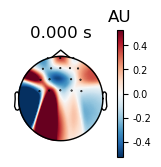

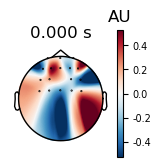

In [41]:
# ---------------------------------------------------------------
#  Side-by-side topomaps for CTRL vs MEM from CSV (MNE ≥ 1.0)
# ---------------------------------------------------------------
import re
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- HELPERS --------------------------------------------
def find_weight_file(cond: str) -> Path:
    """
    Find the CSV for given condition ('ctrl' or 'mem') for the chosen subject.
    If lag_ms is provided, match exactly. Otherwise, take any that matches.
    """
    subj_glob = f"sub-{subject}_eeg_weights_{cond}_*.csv"
    candidates = list((base_dir).glob(subj_glob))
    if not candidates:
        raise FileNotFoundError(f"No {cond.upper()} files found for subject {subject} in {base_dir}")

    if lag_ms is None:
        # Just take the first one (or you could sort by lag magnitude if you prefer)
        return candidates[0]
    else:
        # Normalize lag string to include trailing 'ms' if user passed like '+20' or '-80'
        lag_str = f"{lag_ms}ms" if not str(lag_ms).endswith("ms") else str(lag_ms)
        target_name = f"sub-{subject}_eeg_weights_{cond}_{lag_str}.csv"
        target_path = base_dir / target_name
        if target_path.exists():
            return target_path
        else:
            # Fallback: try to match numerically in case of formatting quirks
            # Extract number from filenames and compare
            def extract_lag(p: Path):
                m = re.search(r'_(?:ctrl|mem)_([+-]?\d+)ms\.csv$', p.name)
                return int(m.group(1)) if m else None
            want = int(str(lag_ms).replace('ms',''))
            by_diff = sorted(
                [p for p in candidates if extract_lag(p) is not None],
                key=lambda p: abs(extract_lag(p) - want)
            )
            if by_diff:
                return by_diff[0]
            raise FileNotFoundError(f"Could not find {cond.upper()} file with lag {lag_ms} for subject {subject}")

def load_weights(csv_path: Path):
    df = pd.read_csv(csv_path)
    ch_names = df['channel'].tolist()
    weights  = df['weight'].to_numpy()
    return ch_names, weights

def main():
    # ---------- LOAD FILES -----------------------------------------
    ctrl_csv = find_weight_file('ctrl')
    mem_csv  = find_weight_file('mem')

    print(f"CTRL file: {ctrl_csv}")
    print(f"MEM  file: {mem_csv}")

    ctrl_ch, ctrl_w = load_weights(ctrl_csv)
    mem_ch,  mem_w  = load_weights(mem_csv)

    # Ensure same channels and order; if not, align memory to control
    if ctrl_ch != mem_ch:
        # align mem to ctrl using a mapping
        idx_map = {ch: i for i, ch in enumerate(mem_ch)}
        mem_w = np.array([mem_w[idx_map[ch]] for ch in ctrl_ch])
        mem_ch = ctrl_ch


    info = mne.create_info(ctrl_ch, sfreq=1000, ch_types='eeg')
    info.set_montage(mne.channels.make_standard_montage(montage_name))

    # reshape to (n_channels, n_times) with one “time sample”
    evoked_ctrl = mne.EvokedArray(ctrl_w.reshape(len(ctrl_ch), 1), info, tmin=0)
    evoked_mem  = mne.EvokedArray(mem_w.reshape(len(mem_ch), 1), info, tmin=0)

    # ------------ 3.  plot the topomap  ----------------------------
    vmax = np.abs(np.concatenate([ctrl_w, mem_w])).max()
    vlim = (-vmax, vmax)

    plot_args = dict(
        times=[0],                      # list for MNE ≥ 1.0
        scalings=1,
        cmap='RdBu_r',
        contours=0,
        sensors=True,
        sphere=sphere
    )

    plot_args['vlim'] = vlim

    fig1 = evoked_ctrl.plot_topomap(**plot_args)
    fig2 = evoked_mem.plot_topomap(**plot_args)
    plt.show()

# ---------- USER INPUTS ----------------------------------------
subject = "097"                              # <-- e.g., "076"
lag_ms  = None                               # <-- e.g., "+20" or "-80"; or None to auto-pick
base_dir = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\weights2")
montage_name = 'standard_1020'               # change if you use another montage
sphere = 0.09                                # MNE head sphere (meters); tweak if needed
cmap = 'RdBu_r'
main()